2.1 Errorbars and regression

In [188]:
# Packages:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor

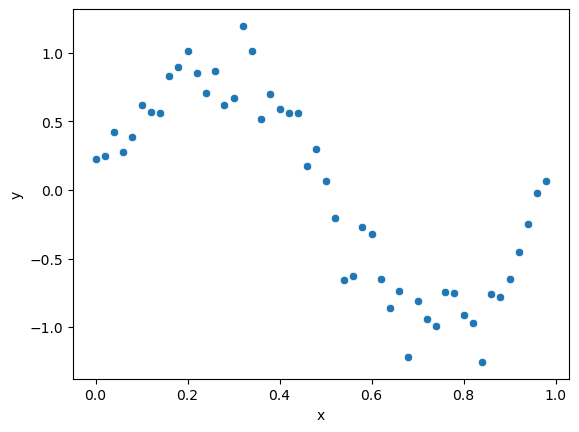

In [189]:
# 1.
data = pd.read_csv("data_sin.csv",sep=",")

sns.scatterplot(data, x="x",y="y")
plt.show()

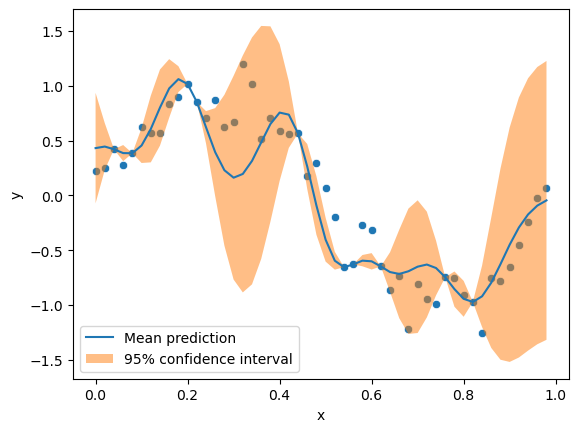

In [190]:
# 2.

# Pick 5 random training points:
n = data.shape[0]
X = data["x"].values.reshape(-1, 1)
y = data["y"].values
rng = np.random.RandomState(0)
indices = rng.choice(np.arange(n), size=int(n/5), replace=False)
X_train, y_train = X[indices], y[indices]

# Fit a Gaussian process regression model to the training data:
gaussian_process = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=9
)
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

sns.scatterplot(data, x="x",y="y")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

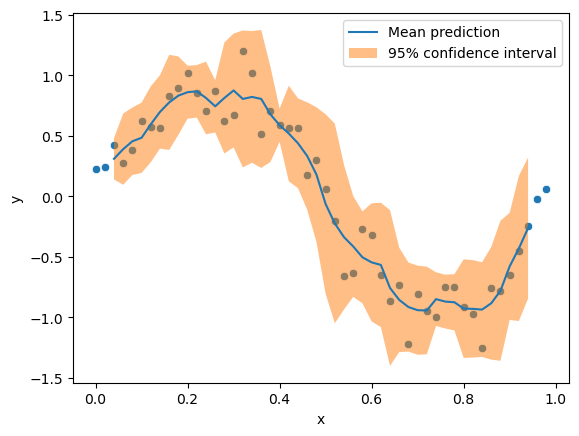

In [191]:
# 3.

# Calculating statistics for each row based on the rolling window of the two previous and two next rows:
x_means = data['x'].rolling(window=5, center=True).mean().values
y_means = data['y'].rolling(window=5, center=True).mean().values
y_stds  = data['y'].rolling(window=5, center=True).std().values


sns.scatterplot(data, x="x",y="y")
plt.plot(X, y_means, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    y_means - 1.96 * y_stds,
    y_means + 1.96 * y_stds,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()